# 08 · From Structure to a Strategy — An Honest Answer

The natural question: can all this structure make money? The honest answer is
**yes for risk, no for return**. Direction is unforecastable (we proved it at every
level), so nothing here bets on which way a price goes. But the **clock**
(volatility) *is* forecastable — so we can manage **risk**: size positions inversely
to forecast risk and de-risk ahead of turbulence. The win is a smoother ride, not a
bigger return.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


## 1. Tail losses live where the clock is high

First, the reason a risk strategy can work at all. Split days by whether the clock
(recent volatility) is high or low, and look at the worst 5% of next-day losses (the
**expected shortfall**). The tail is far deeper when the clock is high — so avoiding
those days removes the fat part of the tail.

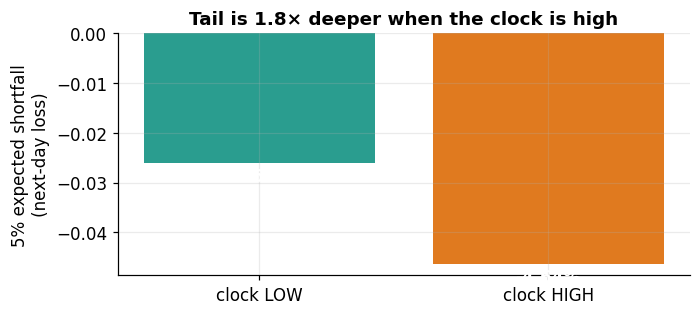

In [2]:
from shared_clock import aligned_prices
import math, statistics
names, M = aligned_prices()
R = [[math.log(M[i][t]/M[i][t-1]) for t in range(1, len(M[i]))] for i in range(len(names))]

def cvar(xs, q=0.05):
    k = max(1, int(q*len(xs))); return statistics.mean(sorted(xs)[:k])

hi, lo = [], []
for r in R:
    clock = [statistics.pstdev(r[t-21:t]) if t >= 21 else 0.0 for t in range(len(r))]
    valid = list(range(21, len(r)-1))
    thr = sorted(clock[t] for t in valid)[int(2/3*len(valid))]
    hi.append(cvar([r[t+1] for t in valid if clock[t] >= thr]))
    lo.append(cvar([r[t+1] for t in valid if clock[t] <  thr]))

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar(["clock LOW", "clock HIGH"], [np.mean(lo), np.mean(hi)], color=[OK, BAD])
ax.set_ylabel("5% expected shortfall\n(next-day loss)")
ax.set_title(f"Tail is {np.mean(hi)/np.mean(lo):.1f}× deeper when the clock is high")
for i, v in enumerate([np.mean(lo), np.mean(hi)]):
    ax.text(i, v-0.001, f"{v:.2%}", ha="center", va="top", color="white", fontweight="bold")
plt.tight_layout(); plt.show()

## 2. The backtest: buy-and-hold vs volatility targeting

We run a walk-forward, cost-aware portfolio over ~30 years. Everything uses only
past data. **A** is plain buy-and-hold. **B/C** target a constant volatility, scaling
exposure down when the forecast clock is loud. No scheme ever bets on direction.

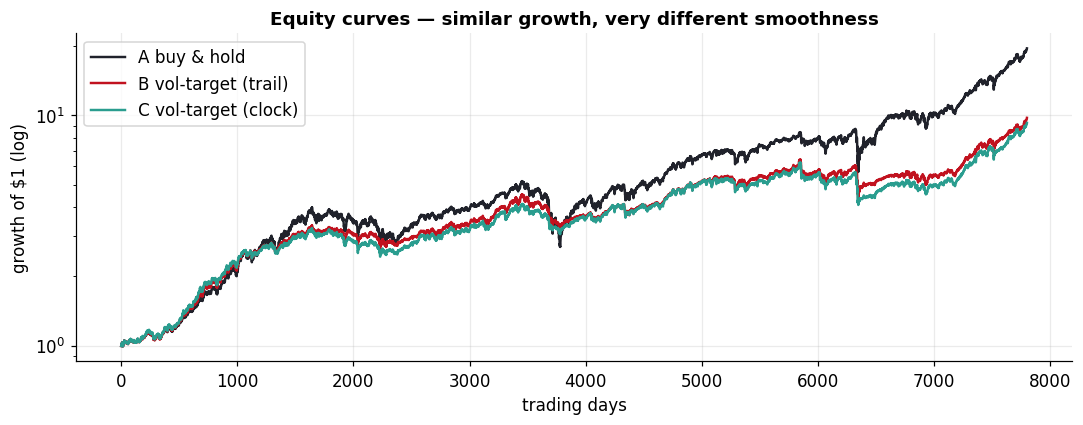

In [3]:
from strategy import backtest, metrics
Rs = [[M[i][t]/M[i][t-1]-1 for t in range(1, len(M[i]))] for i in range(len(names))]   # simple returns

schemes = {
    "A buy & hold":        dict(scheme="buyhold",   vol_forecast="trailing"),
    "B vol-target (trail)":dict(scheme="voltarget", vol_forecast="trailing"),
    "C vol-target (clock)":dict(scheme="voltarget", vol_forecast="har"),
}
results = {}
for label, kw in schemes.items():
    bt = backtest(Rs, target_vol=0.10, lev_cap=1.5, cost_bps=10, warmup=252, **kw)
    results[label] = (bt["daily"], metrics(bt["daily"], warmup=252))

fig, ax = plt.subplots(figsize=(10, 4))
colors = {"A buy & hold": INK, "B vol-target (trail)": HL, "C vol-target (clock)": OK}
for label, (daily, _) in results.items():
    eq = np.cumprod([1+x for x in daily[252:]])
    ax.plot(eq, label=label, color=colors[label], lw=1.6)
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log)"); ax.set_xlabel("trading days")
ax.legend(); ax.set_title("Equity curves — similar growth, very different smoothness")
plt.tight_layout(); plt.show()

## 3. The scoreboard

The vol-targeted schemes barely change the Sharpe ratio, but they **slash the worst
drawdown and the tail loss**. That is the whole point: a much smoother ride for a
similar risk-adjusted return.

/var/folders/54/tt8_6d357691t8wwz7yxv9880000gn/T/ipykernel_91661/1347769400.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(title, fontsize=10); ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
/var/folders/54/tt8_6d357691t8wwz7yxv9880000gn/T/ipykernel_91661/1347769400.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(title, fontsize=10); ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
/var/folders/54/tt8_6d357691t8wwz7yxv9880000gn/T/ipykernel_91661/1347769400.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(title, fontsize=10); ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)


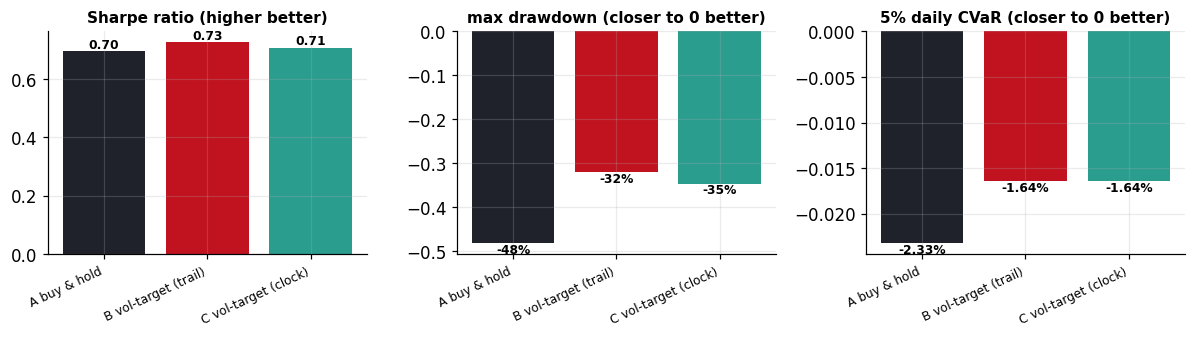

scheme                 Sharpe   maxDD    CVaR5%
A buy & hold            0.70    -48%   -2.33%
B vol-target (trail)    0.73    -32%   -1.64%
C vol-target (clock)    0.71    -35%   -1.64%


In [4]:
labels = list(results.keys())
sharpe = [results[l][1]["sharpe"] for l in labels]
mdd    = [results[l][1]["max_drawdown"] for l in labels]
cv     = [results[l][1]["cvar_5pct_daily"] for l in labels]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, vals, title, fmt in zip(
        axes, [sharpe, mdd, cv],
        ["Sharpe ratio (higher better)", "max drawdown (closer to 0 better)", "5% daily CVaR (closer to 0 better)"],
        ["{:.2f}", "{:.0%}", "{:.2%}"]):
    bars = ax.bar(labels, vals, color=[INK, HL, OK])
    ax.set_title(title, fontsize=10); ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v, fmt.format(v), ha="center",
                va="bottom" if v >= 0 else "top", fontsize=8, fontweight="bold")
plt.tight_layout(); plt.show()

print("scheme                 Sharpe   maxDD    CVaR5%")
for l in labels:
    m = results[l][1]
    print(f"{l:22s} {m['sharpe']:5.2f}  {m['max_drawdown']:6.0%}  {m['cvar_5pct_daily']:7.2%}")

## Takeaways — and the honest ceiling

* Because tail losses **concentrate where the clock is high**, de-risking on the
  clock removes the fat part of the tail.
* Volatility targeting cuts the **worst drawdown by about a third** and the daily
  tail loss by ~30%, at a **marginally better Sharpe** — a materially smoother ride.
* But there is **no return alpha**: the fancy clock forecast does not beat simple
  trailing volatility once trading costs are paid, and *direction is unforecastable*.
  The programme buys **understanding and risk control**, not a money machine.

## The whole journey, in one line

An **exact inverse** for deterministic networks (00–02) meets **markets** and fails
honestly (03); dropping the assumption that digits carry the information (04),
markets reveal a **self-similar, shared, fractal clock** in the timing of their
turning points (05–07) — real structure that governs **risk**, not direction (08).